In [1]:
!pip uninstall -y transformers
!pip install -q transformers==4.52.4 accelerate huggingface_hub kagglehub
!pip install -q bitsandbytes
!pip install -q pillow matplotlib pandas faiss-cpu gradio
!pip install -q colpali-engine

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 62.7 MB/s eta 0:00:00


In [2]:
import torch
import transformers

print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Transformers: 5.8.1
CUDA available: True
Using device: cuda


In [4]:
from huggingface_hub import notebook_login, whoami

notebook_login()
print(whoami())

{'type': 'user', 'id': '69e3635098d4268d976949b2', 'name': 'Salma2004-salma', 'fullname': 'Salma Khairy Abdelsalam', 'isPro': False, 'avatarUrl': '/avatars/d272a213b1846ea9ab2892302e2d2e3b.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'colab-medgemma', 'role': 'fineGrained', 'createdAt': '2026-05-16T07:07:10.330Z', 'fineGrained': {'canReadGatedRepos': True, 'global': [], 'scoped': [{'entity': {'_id': '69e3635098d4268d976949b2', 'type': 'user', 'name': 'Salma2004-salma'}, 'permissions': ['inference.serverless.write']}]}}}}


In [5]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

model_id = "google/medgemma-4b-it"

processor = AutoProcessor.from_pretrained(model_id)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

model.eval()

print("MEDGEMMA 4B LOADED SUCCESSFULLY")

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

MEDGEMMA 4B LOADED SUCCESSFULLY


In [6]:
import kagglehub
import glob

path = kagglehub.dataset_download(
    "simhadrisadaram/mimic-cxr-dataset"
)

print("Dataset path:", path)

images = glob.glob(path + "/**/*.jpg", recursive=True)
images += glob.glob(path + "/**/*.png", recursive=True)
images += glob.glob(path + "/**/*.jpeg", recursive=True)

print("Total images:", len(images))

LIMIT = 300
sample_images = images[:LIMIT]

print("Using:", len(sample_images))
print("First image:", sample_images[0])

Using Colab cache for faster access to the 'mimic-cxr-dataset' dataset.
Dataset path: /kaggle/input/mimic-cxr-dataset
Total images: 261137
Using: 300
First image: /kaggle/input/mimic-cxr-dataset/official_data_iccv_final/files/p18/p18726783/s55239487/010be740-69e8ee45-48f96394-fc59ceb3-caffa275.jpg


In [6]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = sample_images[0]
image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

print("Using image:", image_path)

In [7]:
def generate_medgemma_report(img):
    img = img.convert("RGB")
    img.thumbnail((896, 896))

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": img},
                {
                    "type": "text",
                    "text": (
                        "You are an expert radiologist. "
                        "Analyze this chest X-ray image and generate a structured radiology report.\n\n"
                        "Use exactly this format:\n\n"
                        "Findings:\n"
                        "Impression:"
                    ),
                },
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )

    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    input_len = inputs["input_ids"].shape[-1]

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=True,
            temperature=0.4,
            top_p=0.9,
            repetition_penalty=1.05,
            pad_token_id=processor.tokenizer.eos_token_id
        )

    new_tokens = output_ids[:, input_len:]

    report = processor.batch_decode(
        new_tokens,
        skip_special_tokens=True
    )[0].strip()

    return report

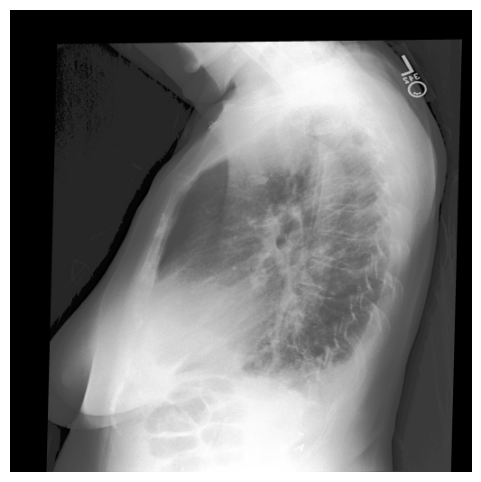

Using image: /kaggle/input/mimic-cxr-dataset/official_data_iccv_final/files/p18/p18726783/s55239487/010be740-69e8ee45-48f96394-fc59ceb3-caffa275.jpg
Generated Report:
'Findings:\n*   The lungs appear clear bilaterally, with no obvious signs of consolidation, effusion, or pneumothorax.\n*   The heart size is within normal limits.\n*   The mediastinum appears unremarkable.\n*   There is no evidence of significant bony abnormalities.\n\nImpression:\nNo acute cardiopulmonary findings identified on this chest X-ray.'
Findings:
*   The lungs appear clear bilaterally, with no obvious signs of consolidation, effusion, or pneumothorax.
*   The heart size is within normal limits.
*   The mediastinum appears unremarkable.
*   There is no evidence of significant bony abnormalities.

Impression:
No acute cardiopulmonary findings identified on this chest X-ray.


In [11]:
# شغلي هذه الخلية أولاً لإعادة تعريف image

from PIL import Image
import matplotlib.pyplot as plt

# اختيار أول صورة من البيانات
image_path = sample_images[0]

# فتح الصورة
image = Image.open(image_path).convert("RGB")

# عرض الصورة
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

print("Using image:", image_path)

# الآن اختبري توليد التقرير
report = generate_medgemma_report(image)

print("Generated Report:")
print(repr(report))
print(report)

In [12]:
report = generate_medgemma_report(image)

print("Generated Report:")
print(repr(report))
print(report)

Generated Report:
'Findings:\n*   The lungs appear clear bilaterally, with no obvious consolidation, effusion, or pneumothorax.\n*   The heart size is within normal limits.\n*   The mediastinum is unremarkable.\n*   There is no evidence of significant pulmonary vascular congestion.\n*   The bony structures are intact.\n\nImpression:\nNo acute cardiopulmonary abnormalities identified on this chest X-ray.'
Findings:
*   The lungs appear clear bilaterally, with no obvious consolidation, effusion, or pneumothorax.
*   The heart size is within normal limits.
*   The mediastinum is unremarkable.
*   There is no evidence of significant pulmonary vascular congestion.
*   The bony structures are intact.

Impression:
No acute cardiopulmonary abnormalities identified on this chest X-ray.


In [13]:
generated_reports = []

N_REPORTS = 5

for i, img_path in enumerate(sample_images[:N_REPORTS]):
    img = Image.open(img_path).convert("RGB")
    rep = generate_medgemma_report(img)

    generated_reports.append({
        "image_path": img_path,
        "report": rep
    })

    print(f"Done {i+1}/{N_REPORTS}")
    print(rep)
    print("-" * 60)

Done 1/5
Findings:
*   The lungs appear clear bilaterally, with no obvious consolidation, effusion, or pneumothorax.
*   The heart size is within normal limits.
*   The mediastinum is unremarkable.
*   There is no evidence of acute bony abnormalities.

Impression:
No acute cardiopulmonary process identified.
------------------------------------------------------------
Done 2/5
Findings:
*   **Cardiomegaly:** The heart appears enlarged, with increased prominence of the cardiac silhouette.
*   **Blunting of Costophrenic Angles:** There is blunting of the right costophrenic angle, which could indicate a small pleural effusion or pleural thickening.
*   **Possible Right Lower Lobe Opacity:** There may be some increased opacity in the right lower lung field, potentially representing consolidation or atelectasis.
*   **No Obvious Pneumothorax:** No large pneumothorax is immediately apparent.

Impression:
The findings suggest possible cardiomegaly and possibly a small pleural effusion on the 

Load CLIP

In [14]:
from transformers import CLIPProcessor, CLIPModel
import numpy as np
import faiss

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

clip_model.eval()

print("CLIP LOADED SUCCESSFULLY")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP LOADED SUCCESSFULLY


In [15]:
def get_clip_image_embedding(img):
    inputs = clip_processor(
        images=img,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = clip_model.get_image_features(
            pixel_values=inputs["pixel_values"]
        )

    if hasattr(outputs, "image_embeds"):
        emb = outputs.image_embeds
    elif hasattr(outputs, "pooler_output"):
        emb = outputs.pooler_output
    elif hasattr(outputs, "last_hidden_state"):
        emb = outputs.last_hidden_state[:, 0, :]
    else:
        emb = outputs

    emb = emb / emb.norm(dim=-1, keepdim=True)

    return emb.cpu().numpy().astype("float32")

Build FAISS

In [16]:
clip_embeddings = []

for item in generated_reports:
    img = Image.open(item["image_path"]).convert("RGB")
    emb = get_clip_image_embedding(img)
    clip_embeddings.append(emb[0])

clip_embeddings = np.array(clip_embeddings).astype("float32")

index = faiss.IndexFlatIP(clip_embeddings.shape[1])
index.add(clip_embeddings)

print("FAISS index ready")
print("Indexed items:", index.ntotal)

FAISS index ready
Indexed items: 5


Retrieval

In [17]:
def retrieve_similar_cases(query_image, k=3):
    k = min(k, len(generated_reports))

    query_emb = get_clip_image_embedding(query_image)

    scores, indices = index.search(query_emb, k)

    results = []

    for score, idx in zip(scores[0], indices[0]):
        results.append({
            "score": float(score),
            "image_path": generated_reports[idx]["image_path"],
            "report": generated_reports[idx]["report"]
        })

    return results

QA Mode

In [18]:
def answer_question_with_rag(query_image, question, k=3):
    retrieved_cases = retrieve_similar_cases(query_image, k=k)

    context = ""

    for i, case in enumerate(retrieved_cases):
        context += f"""
Retrieved Case {i+1}
Similarity Score: {case['score']}
Report:
{case['report']}
"""

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": query_image},
                {
                    "type": "text",
                    "text": f"""
You are a medical visual question answering assistant.

Use the chest X-ray image and the retrieved reports below.
Answer only using supported evidence.

Retrieved Context:
{context}

Question:
{question}

Answer:
"""
                },
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )

    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    input_len = inputs["input_ids"].shape[-1]

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=True,
            temperature=0.4,
            top_p=0.9,
            repetition_penalty=1.05,
            pad_token_id=processor.tokenizer.eos_token_id
        )

    new_tokens = output_ids[:, input_len:]

    answer = processor.batch_decode(
        new_tokens,
        skip_special_tokens=True
    )[0].strip()

    return answer, retrieved_cases

Test QA

In [19]:
question = "Are the lungs clear?"

answer, retrieved = answer_question_with_rag(image, question)

print("Question:")
print(question)

print("\nAnswer:")
print(answer)

print("\nRetrieved Evidence:")
for r in retrieved:
    print("Score:", r["score"])
    print(r["report"])
    print("-" * 50)

Question:
Are the lungs clear?

Answer:
Yes, the lungs appear clear bilaterally, with no obvious consolidation, effusion, or pneumothorax.

Retrieved Evidence:
Score: 1.0
Findings:
*   The lungs appear clear bilaterally, with no obvious consolidation, effusion, or pneumothorax.
*   The heart size is within normal limits.
*   The mediastinum is unremarkable.
*   There is no evidence of acute bony abnormalities.

Impression:
No acute cardiopulmonary process identified.
--------------------------------------------------
Score: 0.9210653305053711
Findings:
*   **Cardiomegaly:** The heart appears enlarged, with increased prominence of the cardiac silhouette.
*   **Blunting of Costophrenic Angles:** There is blunting of the right costophrenic angle, which could indicate a small pleural effusion or pleural thickening.
*   **Possible Right Lower Lobe Opacity:** There may be some increased opacity in the right lower lung field, potentially representing consolidation or atelectasis.
*   **No Obv

ColPali

In [20]:
try:
    from colpali_engine.models import ColPali, ColPaliProcessor

    colpali_model_id = "vidore/colpali-v1.2"

    colpali_processor = ColPaliProcessor.from_pretrained(
        colpali_model_id
    )

    print("ColPali processor loaded successfully")

    try:
        colpali_model = ColPali.from_pretrained(
            colpali_model_id,
            torch_dtype=torch.float16,
            device_map="auto"
        ).eval()

        print("COLPALI MODEL LOADED SUCCESSFULLY")

    except Exception as model_error:
        colpali_model = None
        print("ColPali full model could not be loaded due to GPU/memory limits.")
        print(model_error)

except Exception as e:
    print("ColPali integration issue:")
    print(e)

preprocessor_config.json:   0%|          | 0.00/700 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

ColPali processor loaded successfully


...

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/605 [00:00<?, ?it/s]

ColPali full model could not be loaded due to GPU/memory limits.
Found an incompatible version of torchao. Found version 0.10.0, but only versions above 0.16.0 are supported


Comparison

In [21]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Model": "MedGemma 4B",
        "Used For": "Report Generation and QA Answering",
        "Strength": "Medical vision-language reasoning",
        "Limitation": "Requires gated Hugging Face access and GPU memory"
    },
    {
        "Model": "CLIP + FAISS",
        "Used For": "Image retrieval for RAG",
        "Strength": "Fast image similarity search",
        "Limitation": "Not medically specialized"
    },
    {
        "Model": "ColPali",
        "Used For": "Mandatory multimodal retrieval integration",
        "Strength": "Strong visual-document retrieval",
        "Limitation": "Full model requires high GPU memory"
    }
])

comparison

,Model,Used For,Strength,Limitation
0,MedGemma 4B,Report Generation and QA Answering,Medical vision-language reasoning,Requires gated Hugging Face access and GPU memory
1,CLIP + FAISS,Image retrieval for RAG,Fast image similarity search,Not medically specialized
2,ColPali,Mandatory multimodal retrieval integration,Strong visual-document retrieval,Full model requires high GPU memory


Gradio

In [ ]:
import gradio as gr
from PIL import Image

def gradio_report_mode(input_image):
    img = Image.fromarray(input_image).convert("RGB")
    report = generate_medgemma_report(img)

    if report is None or str(report).strip() == "":
        return "MedGemma returned an empty output. Please try another X-ray image."

    return str(report)

def gradio_qa_mode(input_image, question):
    img = Image.fromarray(input_image).convert("RGB")

    answer, retrieved_cases = answer_question_with_rag(
        img,
        question,
        k=3
    )

    evidence = ""

    for i, case in enumerate(retrieved_cases):
        evidence += f"\n--- Retrieved Case {i+1} ---\n"
        evidence += f"Score: {case['score']}\n"
        evidence += case["report"] + "\n"

    return answer, evidence

with gr.Blocks() as demo:
    gr.Markdown("# Multi-Modal Chest-X-Ray Intelligence System")
    gr.Markdown(
        "Dual-mode system: MedGemma Report Generation + RAG-based QA using CLIP/FAISS and ColPali integration."
    )

    with gr.Tab("Report Generation Mode"):
        img_input = gr.Image(type="numpy", label="Upload Chest X-ray")
        report_output = gr.Textbox(label="Generated Chest X-ray Report", lines=10)
        report_btn = gr.Button("Generate Report")

        report_btn.click(
            gradio_report_mode,
            inputs=img_input,
            outputs=report_output
        )

    with gr.Tab("QA Mode"):
        qa_img = gr.Image(type="numpy", label="Upload Chest X-ray")
        qa_question = gr.Textbox(
            label="Ask a clinical question",
            placeholder="Example: Are the lungs clear?"
        )
        qa_answer = gr.Textbox(label="Answer", lines=6)
        qa_evidence = gr.Textbox(label="Retrieved Evidence", lines=12)
        qa_btn = gr.Button("Ask Question")

        qa_btn.click(
            gradio_qa_mode,
            inputs=[qa_img, qa_question],
            outputs=[qa_answer, qa_evidence]
        )

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://808c2e16a297de17d8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
image_path = sample_images[10]
image = Image.open(image_path).convert("RGB")
report = generate_medgemma_report(image)
print(report)